In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# df_capped120_q1   = pd.read_csv("../tables/pubmed_central_20260309_183439.tsv", sep="\t")
# df_capped200_q1   = pd.read_csv("../tables/pubmed_central_20260309_184017.tsv", sep="\t")
# df_uncapped_q1 = pd.read_csv("../tables/pubmed_central_20260309_182908.tsv", sep="\t")
# df_capped120_q2   = pd.read_csv("../tables/pubmed_central_20260309_180315.tsv", sep="\t")
# df_capped200_q2   = pd.read_csv("../tables/pubmed_central_20260309_185606.tsv", sep="\t")
# df_uncapped_q2 = pd.read_csv("../tables/pubmed_central_20260309_181417.tsv", sep="\t")

df_capped150_q1   = pd.read_csv("../tables/pubmed_central_20260312_093311.tsv", sep="\t")
df_capped150_q2   = pd.read_csv("../tables/pubmed_central_20260312_094127.tsv", sep="\t")
df_capped150_q3  = pd.read_csv("../tables/pubmed_central_20260312_111548.tsv", sep="\t")

In [3]:
import sys, os, textwrap
from collections import Counter
sys.path.insert(0, "../scrapers")
from scrape_publications import build_search_query, build_search_query_v2, build_search_query_v3

datasets = {
    "Q1 Capped 150": df_capped150_q1,
    "Q2 Capped 150": df_capped150_q2,
    "Q3 Capped 150": df_capped150_q3,
}

# ── Metrics ───────────────────────────────────────────────────────────────────
metrics = {}
for label, df in datasets.items():
    counts = df["Abbreviation"].value_counts()
    # Top 5 authors
    all_authors = []
    if "Authors" in df.columns:
        for authors in df["Authors"].dropna():
            all_authors.extend([a.strip() for a in str(authors).split(";")])
    top5_authors = Counter(all_authors).most_common(5)
    metrics[label] = {
        "Total records":          len(df),
        "Unique studies w/ hits": len(counts),
        "Max per study":          int(counts.max()),
        "Median per study":       round(float(counts.median()), 1),
        "top10":                  [f"{s} ({c})" for s, c in counts.head(10).items()],
        "top5_authors":           [f"{a} ({c})" for a, c in top5_authors],
    }

# ── Query examples ────────────────────────────────────────────────────────────
sample = df_capped150_q1.iloc[0]
q1_example = build_search_query(
    sample["Study Name"], sample["Abbreviation"],
    sample.get("Diseases Included", ""), sample.get("Coarse Data Modality", ""))
q2_example = build_search_query_v2(
    sample["Study Name"], sample["Abbreviation"],
    sample.get("Diseases Included", ""), sample.get("Coarse Data Modality", ""))
q3_example = build_search_query_v3(
    sample["Study Name"], sample["Abbreviation"],
    sample.get("Diseases Included", ""), sample.get("Coarse Data Modality", ""))

# ── Layout constants ──────────────────────────────────────────────────────────
col_w  = 22
lbl_w  = 30
labels = list(metrics.keys())
q1_labels = [l for l in labels if l.startswith("Q1")]
q2_labels = [l for l in labels if l.startswith("Q2")]
q3_labels = [l for l in labels if l.startswith("Q3")]
q1_span = len(q1_labels) * (col_w + 2)
q2_span = len(q2_labels) * (col_w + 2)
q3_span = len(q3_labels) * (col_w + 2)
total_w = lbl_w + q1_span + q2_span + q3_span

def hline(): print("-" * total_w)

def span_row(label, q1_text, q2_text, q3_text):
    """Print a row with text wrapping within each group's span."""
    q1_lines = textwrap.wrap(q1_text, width=q1_span - 1) or [""]
    q2_lines = textwrap.wrap(q2_text, width=q2_span - 1) or [""]
    q3_lines = textwrap.wrap(q3_text, width=q3_span - 1) or [""]
    for i in range(max(len(q1_lines), len(q2_lines), len(q3_lines))):
        lbl    = label if i == 0 else ""
        q1_str = (q1_lines[i] if i < len(q1_lines) else "").ljust(q1_span)
        q2_str = (q2_lines[i] if i < len(q2_lines) else "").ljust(q2_span)
        q3_str = (q3_lines[i] if i < len(q3_lines) else "").ljust(q3_span)
        print(f"{lbl:<{lbl_w}}{q1_str}{q2_str}{q3_str}")

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'':>{lbl_w}}{'── Q1 ──':^{q1_span}}{'── Q2 ──':^{q2_span}}{'── Q3 ──':^{q3_span}}")
print(f"{'Metric':<{lbl_w}}" + "".join(f"  {l:>{col_w}}" for l in labels))
hline()

span_row("Query type",
         "All Fields + disease terms + modality terms",
         "tiab only — no disease/modality, skips noisy abbrevs",
         "tiab + disease terms + modality terms")
span_row("Query example", q1_example, q2_example, q3_example)
hline()

for k in ["Total records", "Unique studies w/ hits", "Max per study", "Median per study"]:
    print(f"{k:<{lbl_w}}" + "".join(f"  {str(metrics[l][k]):>{col_w}}" for l in labels))

print(f"\nTop 10 studies")
for i in range(10):
    print(f"  #{i+1:<{lbl_w - 3}}" + "".join(
        f"  {(metrics[l]['top10'][i] if i < len(metrics[l]['top10']) else ''):>{col_w}}"
        for l in labels))

print(f"\nTop 5 authors")
for i in range(5):
    print(f"  #{i+1:<{lbl_w - 3}}" + "".join(
        f"  {(metrics[l]['top5_authors'][i] if i < len(metrics[l]['top5_authors']) else ''):>{col_w}}"
        for l in labels))


                                      ── Q1 ──                ── Q2 ──                ── Q3 ──        
Metric                                   Q1 Capped 150           Q2 Capped 150           Q3 Capped 150
------------------------------------------------------------------------------------------------------
Query type                    All Fields + disease    tiab only — no          tiab + disease terms +  
                              terms + modality terms  disease/modality, skips modality terms          
                                                      noisy abbrevs                                   
Query example                 ("Honolulu-Asia Aging   ("Honolulu-Asia Aging   ("Honolulu-Asia Aging   
                              Study"[All Fields] OR   Study"[tiab]) AND (2023 Study"[tiab]) AND       
                              "HAAS"[All Fields]) AND /03/13:2026/03/12[Date  ("alzheimer's           
                              ("alzheimer's           - Publication])    

In [11]:
# export summary statistics table as CSV
rows = []

query_types = {
    "Q1 Capped 150": "All Fields + disease terms + modality terms",
    "Q2 Capped 150": "tiab only — no disease/modality, skips noisy abbrevs",
    "Q3 Capped 150": "tiab + disease terms + modality terms",
}
query_examples = {
    "Q1 Capped 150": q1_example,
    "Q2 Capped 150": q2_example,
    "Q3 Capped 150": q3_example,
}

for label in labels:
    m = metrics[label]
    row = {
        "Query":             label,
        "Query type":        query_types[label],
        "Query example":     query_examples[label],
        "Total records":     m["Total records"],
        "Unique studies w/ hits": m["Unique studies w/ hits"],
        "Max per study":     m["Max per study"],
        "Median per study":  m["Median per study"],
    }
    for i, val in enumerate(m["top10"], 1):
        row[f"Top study #{i}"] = val
    for i, val in enumerate(m["top5_authors"], 1):
        row[f"Top author #{i}"] = val
    rows.append(row)

export_df = pd.DataFrame(rows).T
out_path = "../paper_v0/v0.3/query_comparison_summary.csv"
export_df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")
export_df


Saved to ../paper_v0/v0.3/query_comparison_summary.csv


,0,1,2
Query,Q1 Capped 150,Q2 Capped 150,Q3 Capped 150
Query type,All Fields + disease terms + modality terms,"tiab only — no disease/modality, skips noisy a...",tiab + disease terms + modality terms
Query example,"(""Honolulu-Asia Aging Study""[All Fields] OR ""H...","(""Honolulu-Asia Aging Study""[tiab]) AND (2023/...","(""Honolulu-Asia Aging Study""[tiab]) AND (""alzh..."
Total records,1717,3631,1574
Unique studies w/ hits,64,82,60
Max per study,150,371,150
Median per study,9.0,15.0,8.0
Top study #1,CODES (150),MCSA (371),NACC (150)
Top study #2,ADNI (146),BLSA (305),ADNI (150)
Top study #3,NACC (140),NACC (150),PPMI (149)


3 [0.20811639 0.17986599]
9 [-0.7317951  -0.99198859]
Saved → ../paper_v0/v0.3/query-method comparison.png


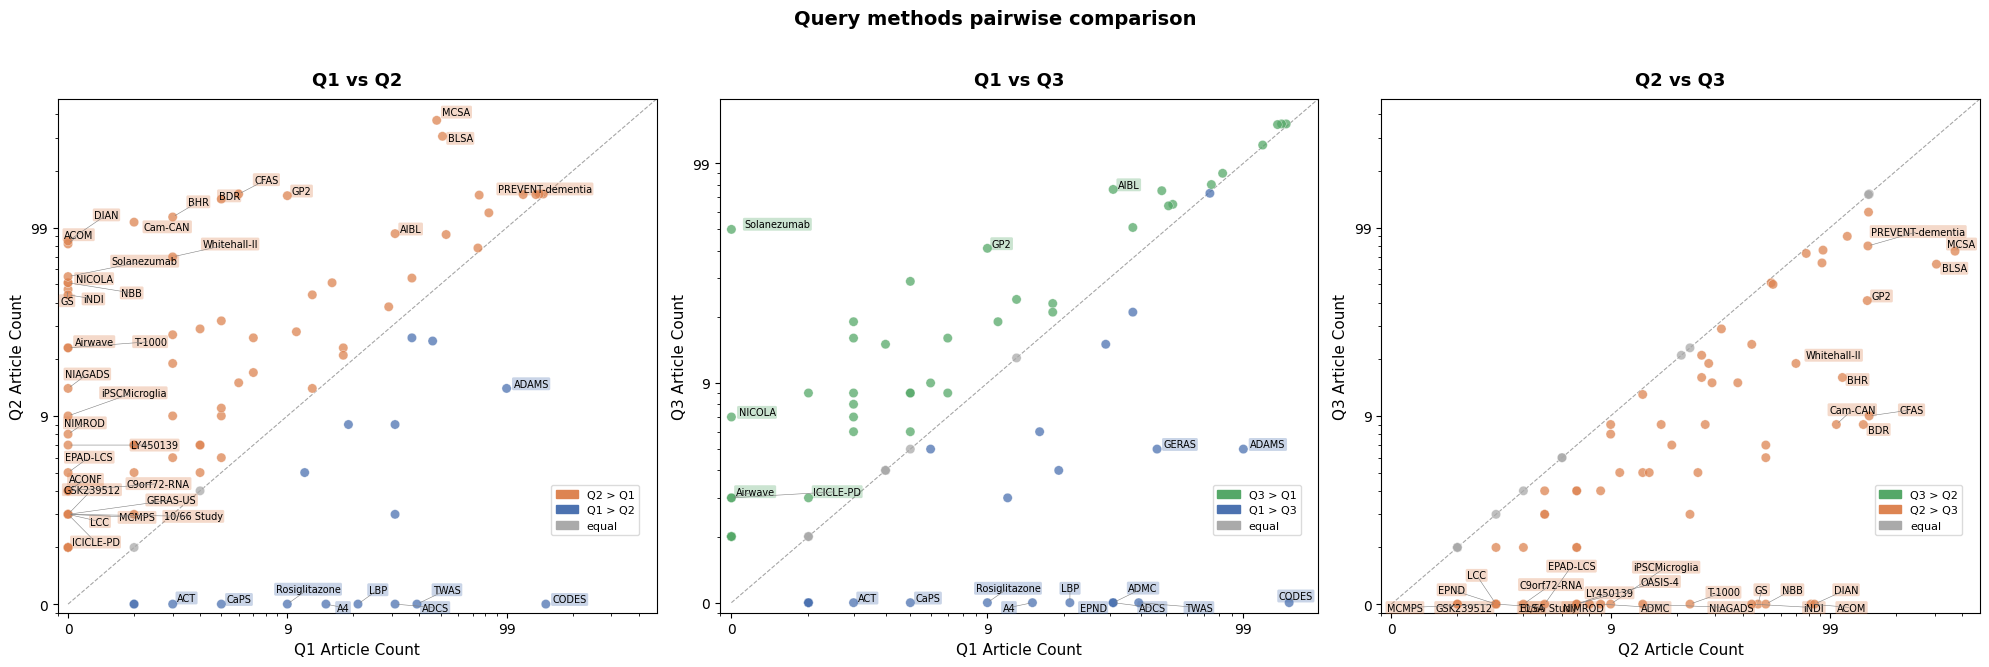

In [17]:
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import numpy as np
from adjustText import adjust_text

pairs = [
    ("Q1 Capped 150", "Q2 Capped 150"),
    ("Q1 Capped 150", "Q3 Capped 150"),
    ("Q2 Capped 150", "Q3 Capped 150"),
]
short   = {"Q1 Capped 150": "Q1", "Q2 Capped 150": "Q2", "Q3 Capped 150": "Q3"}
palette = {"Q1 Capped 150": "#4C72B0", "Q2 Capped 150": "#DD8452", "Q3 Capped 150": "#55A868"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

for ax, (lbl_x, lbl_y) in zip(axes, pairs):
    x_counts = datasets[lbl_x]["Abbreviation"].value_counts()
    y_counts = datasets[lbl_y]["Abbreviation"].value_counts()

    all_abbrevs = sorted(set(x_counts.index) | set(y_counts.index))
    x = np.array([x_counts.get(a, 0) for a in all_abbrevs])
    y = np.array([y_counts.get(a, 0) for a in all_abbrevs])

    x_plot = x + 1
    y_plot = y + 1

    col_x   = palette[lbl_x]
    col_y   = palette[lbl_y]
    col_tie = "#aaaaaa"

    colors = np.where(y > x, col_y, np.where(x > y, col_x, col_tie))
    both_zero = (x == 0) & (y == 0)

    ax.scatter(x_plot[both_zero],  y_plot[both_zero],
               color="#dddddd", alpha=0.35, s=20, edgecolors="none", zorder=1)
    ax.scatter(x_plot[~both_zero], y_plot[~both_zero],
               c=colors[~both_zero], alpha=0.75, s=45,
               edgecolors="white", linewidths=0.3, zorder=2)

    lim = max(x_plot.max(), y_plot.max()) * 1.3
    ax.plot([1, lim], [1, lim], "k--", linewidth=0.8, alpha=0.35, zorder=1)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.9, lim)
    ax.set_ylim(0.9, lim)

    def fmt(val, _): return str(int(round(val - 1)))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(fmt))

    ax.set_xlabel(f"{short[lbl_x]} Article Count", fontsize=11)
    ax.set_ylabel(f"{short[lbl_y]} Article Count", fontsize=11)
    ax.set_title(f"{short[lbl_x]} vs {short[lbl_y]}", fontsize=13, fontweight="bold", pad=10)

    patches = [
        mpatches.Patch(color=col_y,   label=f"{short[lbl_y]} > {short[lbl_x]}"),
        mpatches.Patch(color=col_x,   label=f"{short[lbl_x]} > {short[lbl_y]}"),
        mpatches.Patch(color=col_tie, label="equal"),
    ]
    ax.legend(handles=patches, fontsize=8, loc="lower right",
              bbox_to_anchor=(0.98, 0.14), framealpha=0.7)

    diff = np.abs(y - x)
    threshold = np.percentile(diff[diff > 0], 85) if (diff > 0).any() else 0
    texts = []
    for i, abbrev in enumerate(all_abbrevs):
        is_top_diverger = diff[i] >= threshold and (x[i] > 0 or y[i] > 0)
        is_one_zero = (y[i] == 0 and x[i] > 1) or (x[i] == 0 and y[i] > 1)
        if is_top_diverger or is_one_zero:
            texts.append(ax.text(x_plot[i], y_plot[i], abbrev,
                                 fontsize=7, color="black",
                                 bbox=dict(boxstyle="round,pad=0.15",
                                           fc=colors[i], alpha=0.3, ec="none")))

    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.4),
        expand_points=(3.0, 3.0),
        expand_text=(2.0, 2.0),
        force_text=(2.0, 2.0),
        force_points=(1.5, 1.5),
        avoid_self=True,
    )

plt.suptitle("Query methods pairwise comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

out_path = "../paper_v0/v0.3/query-method comparison.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight")
print(f"Saved → {out_path}")

plt.show()


In [8]:
base_df = pd.read_csv("../tables/dataset-inventory-Mar_11_2026.tab", sep="\t")
object_names = base_df['Study Name']

In [9]:
object_names.to_list()

['Dominantly Inherited Alzheimer Network',
 'Honolulu-Asia Aging Study',
 'Brain Health Data Pilot - Scotland',
 'Incidence of Cognitive Impairment in Cohorts with Longitudinal Evaluation-PD',
 'Aberdeen Children of the 1950s',
 'Brains for Dementia Research',
 'Harvard Biomarker Study',
 "Longitudinal Early-onset Alzheimer's Disease Study",
 "Alzheimer's Disease Connectome Project",
 'Aging, Demographics, and Memory Study',
 "The Alzheimer's Disease Metabolomics Consortium Alzheimer's Disease Neuroimaging Initiative University of Hawaii Gut Metabolites Study",
 'Human iPSC Astrocytes and iMGL Transcripts - MAPT IVS10+16 Mutation Study',
 "Alzheimer's Disease Neuroimaging Initiative",
 "Alzheimer's Disease Sequencing Project",
 "A Phase 2a Study to Evaluate the Effect of Rilapladib (SB-659032) on Biomarkers Related to the Pathogenesis and Progression of Alzheimer's Disease",
 "A Randomised, Double-blind, Placebo-controlled Study to Evaluate the Efficacy and Safety of the H3 Receptor An